In [1]:
from floppity import Retrieval, helpers
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=16)
import torch
from corner import corner
import cloudpickle as pickle
from tqdm import trange
from floppity.simulators import read_ARCiS_input, ARCiS

In [ ]:

R1 = Retrieval.load('/Users/floppityflappity/Work/WISE1828/test_nopca/retrieval.pkl')
R2 = Retrieval.load('/Users/floppityflappity/Work/WISE1828/test_nopca_1/retrieval.pkl')
R3 = Retrieval.load('/Users/floppityflappity/Work/WISE1828/test_nopca_2/retrieval.pkl')
R4 = Retrieval.load('/Users/floppityflappity/Work/WISE1828/test_pca_10/retrieval.pkl')

In [38]:
r=4
post1 = R1.proposals[r].sample((1000,))
# post2 = R2.proposals[r].sample((1000,))
post3 = R3.proposals[r].sample((1000,))
post4 = R4.proposals[r].sample((1000,))

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

In [39]:
full = []
for key in R1.parameters:
    ranges_m = R1.parameters[key]['min']
    ranges_p = R1.parameters[key]['max']
    full.append((ranges_m, ranges_p))

Text(0.5, 0.98, 'R = 4')

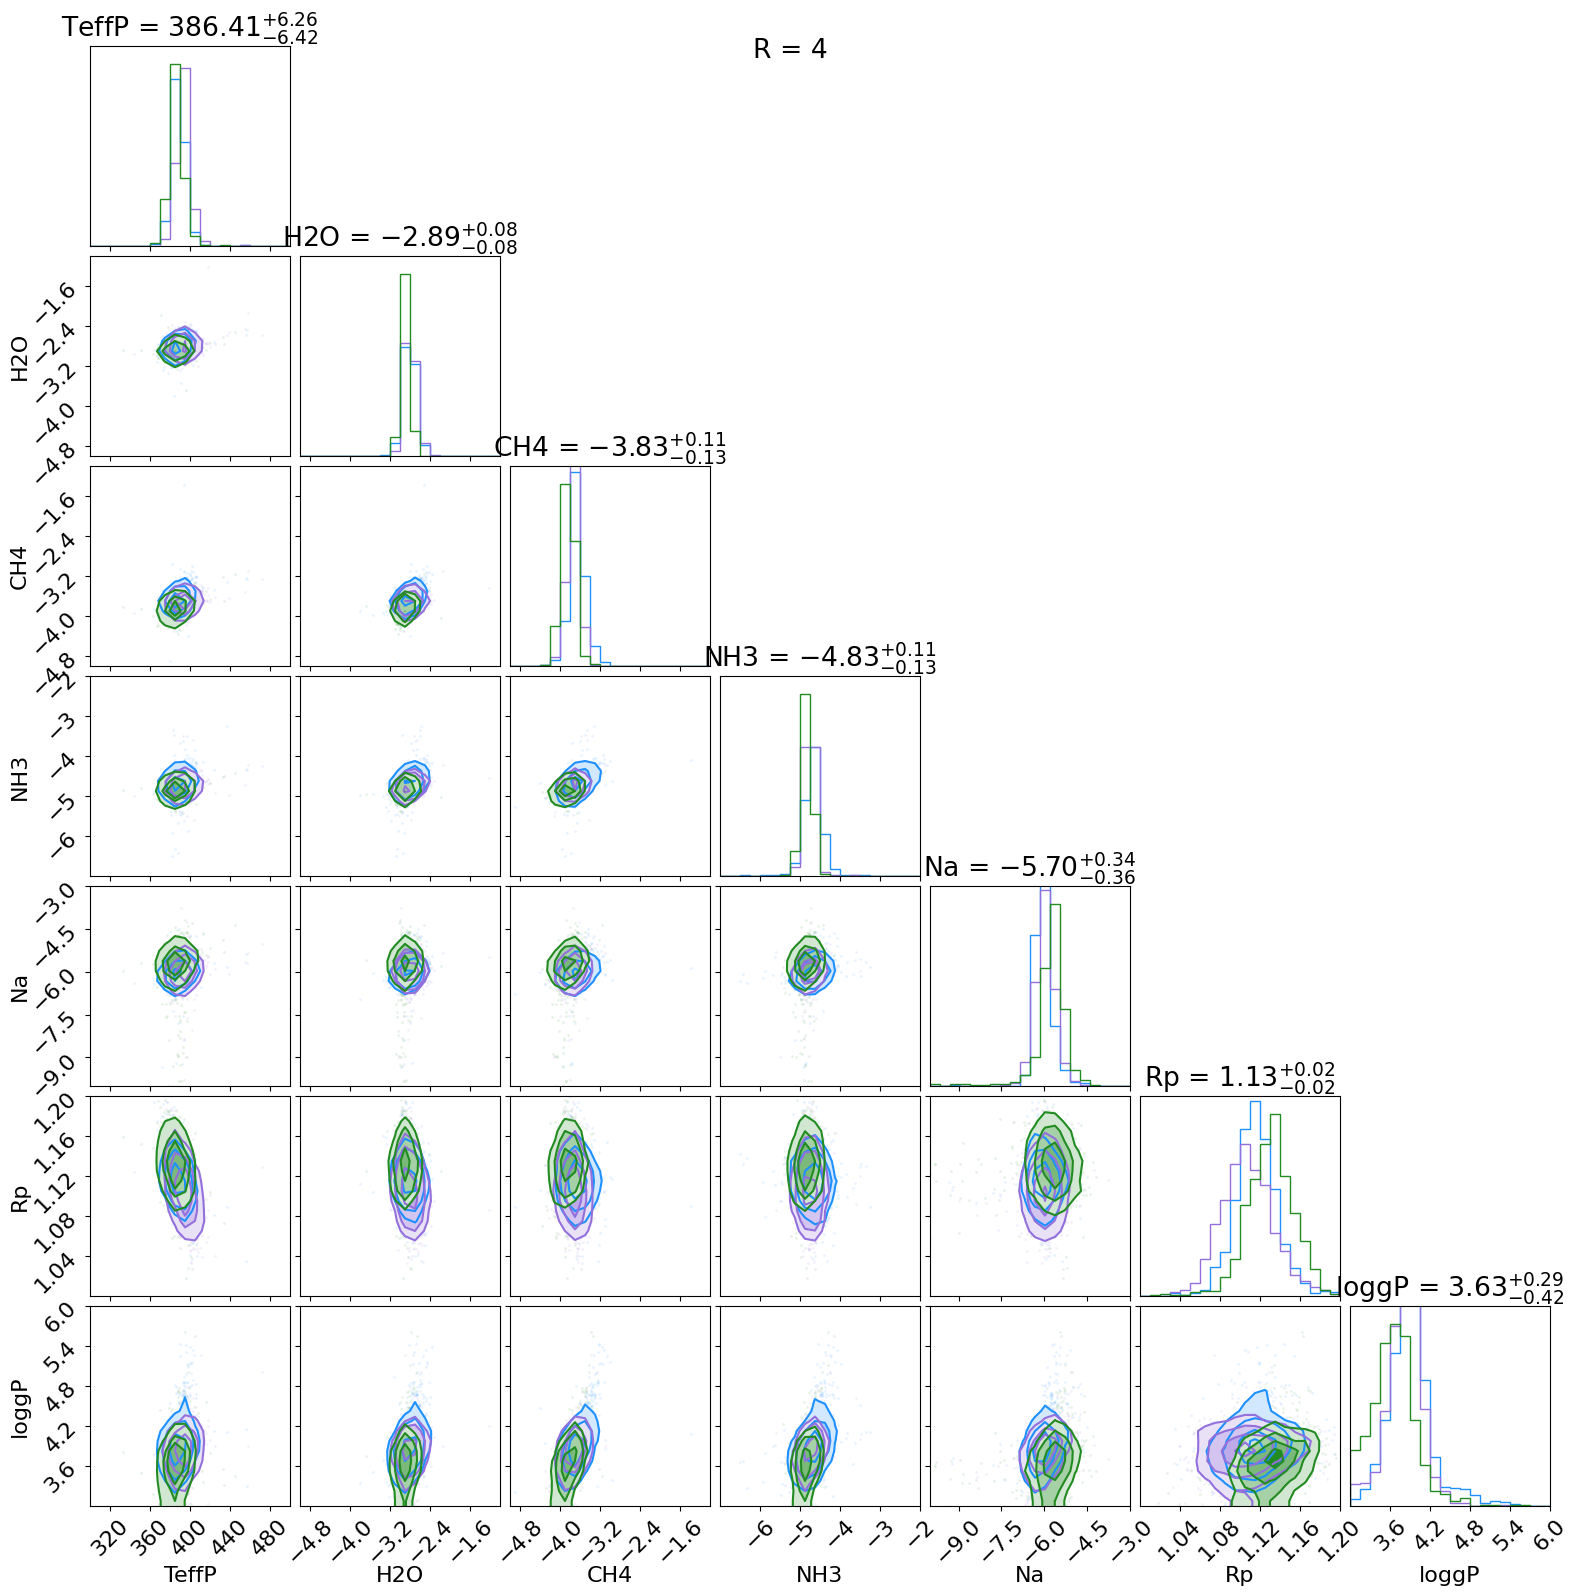

In [40]:
CORNER_KWARGS=dict(
    smooth=0.6,
    # levels=[0.9],
    plot_density=False,
    hist_bin_factor=1,
    plot_contours=True,
    fill_contours=True,
    show_titles=True,
    # range=full,
    range=[(300,500), (-5,-1), (-5,-1), (-7,-2), (-10, -3), (1,1.2), (3,6)],
    labels=list(R1.parameters.keys())
)

fig = corner(post1.detach().numpy(), color='dodgerblue', **CORNER_KWARGS)
# fig2 = corner(post2.detach().numpy(), fig=fig, color='orange', **CORNER_KWARGS)
fig2 = corner(post3.detach().numpy(), fig=fig, color='mediumpurple', **CORNER_KWARGS)
fig2 = corner(post4.detach().numpy(), fig=fig, color='forestgreen', **CORNER_KWARGS)
plt.suptitle(f'R = {r}')

In [ ]:
synth = np.loadtxt(')